In [1]:
!pip install scikit-learn xgboost matplotlib --quiet

import xgboost as xgb
import numpy as np
import pandas as pd
import boto3
import sagemaker
import matplotlib.pyplot as plt
from sagemaker import get_execution_role
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              ConfusionMatrixDisplay)
print("XGBoost version:", xgb.__version__)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
XGBoost version: 3.2.0


In [2]:
import boto3
import pandas as pd
import sagemaker
from sagemaker import get_execution_role
from sagemaker import image_uris
from sagemaker.estimator import Estimator
from sagemaker.inputs import TrainingInput

session = sagemaker.Session()
role    = get_execution_role()
region  = session.boto_region_name
bucket  = 'bilalcsvdata'
PREFIX  = 'churn-data'

print("Role:", role)
print("Region:", region)

Role: arn:aws:iam::5######:role/service-role/#######
Region: us-east-1


In [3]:
s3 = boto3.client('s3')

train_df = pd.read_csv(s3.get_object(Bucket=bucket, Key=f'{PREFIX}/train.csv')['Body'])
val_df   = pd.read_csv(s3.get_object(Bucket=bucket, Key=f'{PREFIX}/validation.csv')['Body'])
test_1   = pd.read_csv(s3.get_object(Bucket=bucket, Key=f'{PREFIX}/test_new_best.csv')['Body'])

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape:  ", test_1.shape)
print("Columns:", train_df.columns.tolist()[:5]) 

Train shape: (4929, 53)
Val shape:   (1055, 53)
Test shape:   (1056, 51)
Columns: ['0', '-0.4381471450281571', '-1.1147282801182177', '0.5042861484510788', '-0.8379380175926643']


In [4]:

xgb_image = image_uris.retrieve(
    framework  = 'xgboost',
    region    = region,
    version   = '1.7-1'
)
print("XGBoost image:", xgb_image)

XGBoost image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1


In [5]:
xgb_estimator = Estimator(
    image_uri         = xgb_image,
    role              = role,
    instance_count    = 1,
    instance_type     = 'ml.m5.xlarge',
    output_path       = f's3://{bucket}/churn/model-output',
    sagemaker_session = session,
    hyperparameters   = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'num_round':        300,
        'scale_pos_weight': 2.77,   
    }
)

In [6]:
train_input = TrainingInput(
    f's3://{bucket}/{PREFIX}/train.csv',
    content_type = 'text/csv'
)
val_input = TrainingInput(
    f's3://{bucket}/{PREFIX}/validation.csv',
    content_type = 'text/csv'
)

In [7]:
from sagemaker.tuner import (
    HyperparameterTuner,
    ContinuousParameter,
    IntegerParameter,
)

hyperparameter_ranges = {
    'eta':              ContinuousParameter(0.01, 0.3),
    'max_depth':        IntegerParameter(3, 9),
    'min_child_weight': ContinuousParameter(1, 10),
    'subsample':        ContinuousParameter(0.5, 1.0),
    'colsample_bytree': ContinuousParameter(0.5, 1.0),
    'gamma':            ContinuousParameter(0.0, 5.0),
    'alpha':            ContinuousParameter(0.0, 2.0),  
    'lambda':           ContinuousParameter(1.0, 10.0), 
}

tuner = HyperparameterTuner(
    estimator             = xgb_estimator,
    objective_metric_name = 'validation:auc',
    objective_type        = 'Maximize',
    hyperparameter_ranges = hyperparameter_ranges,
    max_jobs              = 20,
    max_parallel_jobs     = 3,
    strategy              = 'Bayesian',
    early_stopping_type   = 'Auto',
)

tuner.fit(
    {'train': train_input, 'validation': val_input},
    wait = True,
    logs = False
)
print("HPO complete")
print("Best training job:", tuner.best_training_job())

No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config
No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config


..............................................................................................................!
HPO complete
Best training job: sagemaker-xgboost-260609-1433-019-c28eaba3


In [8]:
best_estimator = tuner.best_estimator()
print("Best hyperparameters:")
for k, v in best_estimator.hyperparameters().items():
    print(f"  {k}: {v}")


2026-06-09 14:41:27 Starting - Found matching resource for reuse
2026-06-09 14:41:27 Downloading - Downloading the training image
2026-06-09 14:41:27 Training - Training image download completed. Training in progress.
2026-06-09 14:41:27 Uploading - Uploading generated training model
2026-06-09 14:41:27 Completed - Resource retained for reuse
Best hyperparameters:
  _tuning_objective_metric: validation:auc
  alpha: 1.2241384907951813
  colsample_bytree: 0.5069428422375319
  eta: 0.014760821054511021
  eval_metric: auc
  gamma: 2.4773889824587196
  lambda: 4.836889500784979
  max_depth: 3
  min_child_weight: 9.957177043219462
  num_round: 300
  objective: binary:logistic
  scale_pos_weight: 2.77
  subsample: 0.6394653928266884


In [9]:
transformer = best_estimator.transformer(
    instance_count = 1,
    instance_type  = 'ml.m5.xlarge',
    output_path    = f's3://{bucket}/churn/batch-output',
)

transformer.transform( 
    data         = f's3://{bucket}/{PREFIX}/test_new_best.csv',
    content_type = 'text/csv',
    split_type   = 'Line',
)
transformer.wait()
print("Batch transform complete")
print("Output at:", transformer.output_path)

INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2026-06-09-14-43-22-973


.................................
/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-06-09:14:48:53:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-09:14:48:53:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-09:14:48:53:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|

In [10]:
response = s3.list_objects_v2(Bucket=bucket, Prefix='churn/batch-output/')
for obj in response.get('Contents', []):
    print(obj['Key'])

churn/batch-output/test_new_best.csv.out


In [11]:
bucket = "bilalcsvdata"
key = "churn/batch-output/test_new_best.csv.out"

local_path = "test_new_best.csv.out"

s3.download_file(bucket, key, local_path)

print("File downloaded locally as:", local_path)

File downloaded locally as: test_new_best.csv.out


In [12]:
import pandas as pd

y_prob = pd.read_csv("test_new_best.csv.out", header=None).iloc[:, 0].values

In [13]:
y_prob

array([0.57422   , 0.22928153, 0.1242058 , ..., 0.54717916, 0.06682373,
       0.74030435], shape=(1057,))

In [14]:
y_pred = (y_prob > 0.5).astype(int)

In [20]:
y_pred
print(type(y_pred))

<class 'numpy.ndarray'>


In [21]:
y_pred = y_pred[1:]

In [22]:
print(y_pred.shape)
print(y_pred[:5])

(1056,)
[0 0 0 0 0]


In [23]:
test_df = pd.read_csv("test.csv")
churn_target = test_df.iloc[:, 0]   


In [17]:
# min_len = min(len(churn_target), len(y_pred))

# churn_target_fixed = churn_target[:min_len]
# y_pred_fixed = y_pred[:min_len]

classification_report:                precision    recall  f1-score   support

           0       0.91      0.73      0.81       776
           1       0.51      0.79      0.62       280

    accuracy                           0.74      1056
   macro avg       0.71      0.76      0.71      1056
weighted avg       0.80      0.74      0.76      1056

  ROC-AUC Score : 0.7574


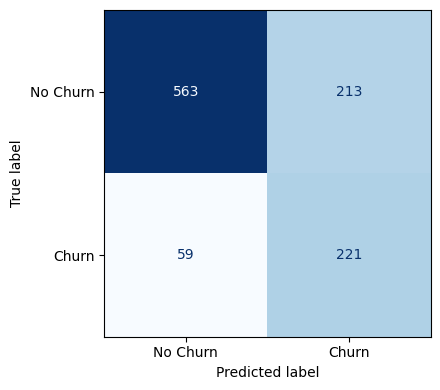

✅ Confusion matrix saved


In [24]:
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix

print("classification_report: ",classification_report(churn_target,y_pred))
print(f"  ROC-AUC Score : {roc_auc_score(churn_target, y_pred):.4f}")

cm   = confusion_matrix(churn_target, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved")




In [25]:
training_job_name = "sagemaker-xgboost-260609-1433-020-83dbc23d"

sm_client = boto3.client("sagemaker", region_name=region)


training_job = sm_client.describe_training_job(TrainingJobName=training_job_name)
model_artifact = training_job["ModelArtifacts"]["S3ModelArtifacts"]
training_image = training_job["AlgorithmSpecification"]["TrainingImage"]

print(f"Model artifact: {model_artifact}")
print(f"Training image: {training_image}")

Model artifact: s3://bilalcsvdata/churn/model-output/sagemaker-xgboost-260609-1433-020-83dbc23d/output/model.tar.gz
Training image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1


In [26]:
model_name = "churn-xgboost-model"

sm_client.create_model(
    ModelName=model_name,
    PrimaryContainer={
        "Image": training_image,
        "ModelDataUrl": model_artifact,
        "Environment": {}
    },
    ExecutionRoleArn=role
)

print(f"Model created: {model_name}")

Model created: churn-xgboost-model


In [27]:
endpoint_config_name = "churn-xgboost-endpoint-config"

sm_client.create_endpoint_config(
    EndpointConfigName=endpoint_config_name,
    ProductionVariants=[
        {
            "VariantName": "AllTraffic",
            "ModelName": model_name,
            "InstanceType": "ml.m5.large",  
            "InitialInstanceCount": 1,
            "InitialVariantWeight": 1.0
        }
    ]
)

print(f"Endpoint config created: {endpoint_config_name}")

Endpoint config created: churn-xgboost-endpoint-config


In [28]:
endpoint_name = "churn-xgboost-endpoint"

sm_client.create_endpoint(
    EndpointName=endpoint_name,
    EndpointConfigName=endpoint_config_name
)

print(f"Endpoint creation initiated: {endpoint_name}")
print("Waiting for endpoint to be InService...")


waiter = sm_client.get_waiter("endpoint_in_service")
waiter.wait(EndpointName=endpoint_name)

print(f"Endpoint is InService: {endpoint_name}")

Endpoint creation initiated: churn-xgboost-endpoint
Waiting for endpoint to be InService...
Endpoint is InService: churn-xgboost-endpoint


In [31]:
import pandas as pd


test_df = pd.read_csv("test.csv", header=None)

X_test = test_df.drop(columns=[0])


sample = X_test.iloc[0].to_csv(header=False, index=False).strip().replace("\n", ",")
print(sample)


2.282338276872113,-0.6277913810478746,-0.6580582729206734,-0.6693968366000825,-1.1493007570436609,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [33]:
import boto3

runtime = boto3.client("sagemaker-runtime", region_name="us-east-1")  

response = runtime.invoke_endpoint(
    EndpointName=endpoint_name,
    ContentType="text/csv",
    Body=sample
)

import json
result = json.loads(response["Body"].read().decode())
print(f"Prediction: {result}")

Prediction: 0.5797376036643982


In [38]:
import boto3
import pandas as pd
import json


test_df = pd.read_csv("test.csv", header=None)


y_true = test_df[0].values
X_test = test_df.drop(columns=[0])

runtime = boto3.client("sagemaker-runtime", region_name="us-east-1")
endpoint_name = "churn-xgboost-endpoint"  

correct = 0
wrong = 0


for i in range(20):
    sample = ",".join(X_test.iloc[i].astype(str).values.tolist())
    response = runtime.invoke_endpoint(
        EndpointName=endpoint_name,
        ContentType="text/csv",
        Body=sample
    )
    prob = json.loads(response["Body"].read().decode())

    y_pred = 1 if prob > 0.5 else 0
    actual = int(y_true[i])
    status = "✅ Correct" if y_pred == actual else "❌ Wrong"
    churn_label = "Churned" if y_pred == 1 else "Not Churned"

    if y_pred == actual:
        correct += 1
    else:
        wrong += 1

    print(f"Row {i+1:2} | Prob: {prob:.4f} | Predicted: {churn_label:<12} | Actual: {'Churned' if actual == 1 else 'Not Churned':<12} | {status}")

# Summary
print(f"\n--- Summary (20 rows) ---")
print(f"✅ Correct: {correct}")
print(f"❌ Wrong:   {wrong}")
print(f"Accuracy:  {correct/20:.2%}")

Row  1 | Prob: 0.5797 | Predicted: Churned      | Actual: Churned      | ✅ Correct
Row  2 | Prob: 0.2537 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  3 | Prob: 0.1641 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  4 | Prob: 0.4399 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  5 | Prob: 0.0974 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  6 | Prob: 0.2914 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  7 | Prob: 0.0519 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  8 | Prob: 0.2544 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row  9 | Prob: 0.2634 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row 10 | Prob: 0.8769 | Predicted: Churned      | Actual: Churned      | ✅ Correct
Row 11 | Prob: 0.5337 | Predicted: Churned      | Actual: Not Churned  | ❌ Wrong
Row 12 | Prob: 0.4240 | Predicted: Not Churned  | Actual: Not Churned  | ✅ Correct
Row 13